In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

#Read data
pd.set_option('display.max_columns', None)
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


#Subset my interested columns
df = data[['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'country_txt', 'region_txt', 'crit1', 'crit2', 'crit3', 'attacktype1_txt', 
           'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targtype2_txt', 'targtype3_txt', 'claimed', 'weaptype1_txt', 'weaptype2_txt',
           'weaptype3_txt', 'nkill', 'nwound', 'property', 'propextent_txt', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']]

df_post2012 = df[df['iyear'] >= 2012]

#-9 is used frequently throughout the data as an 'unknown' indicator. I'm unsure of the difference between this and missing data. It appears to be
#near interchangable to me. Will have to discuss as a group if we'd like to replace -9 with nan, or leave it as -9 and interpret as unknown

#For right now I'm going to replace with nan
df_post2012 = df_post2012.replace(-9, np.nan)
df_post2012 = df_post2012.replace("Unknown", np.nan)

#Make a log transformed column for these values to deal with high variance data
df_post2012['log_nkill'] = np.log1p(df_post2012['nkill'])
df_post2012['log_nwound'] = np.log1p(df_post2012['nwound'])




C:\Users\alist\AppData\Local\Temp\ipykernel_21944\879700079.py:10: DtypeWarning: Columns (4,31,33,54,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


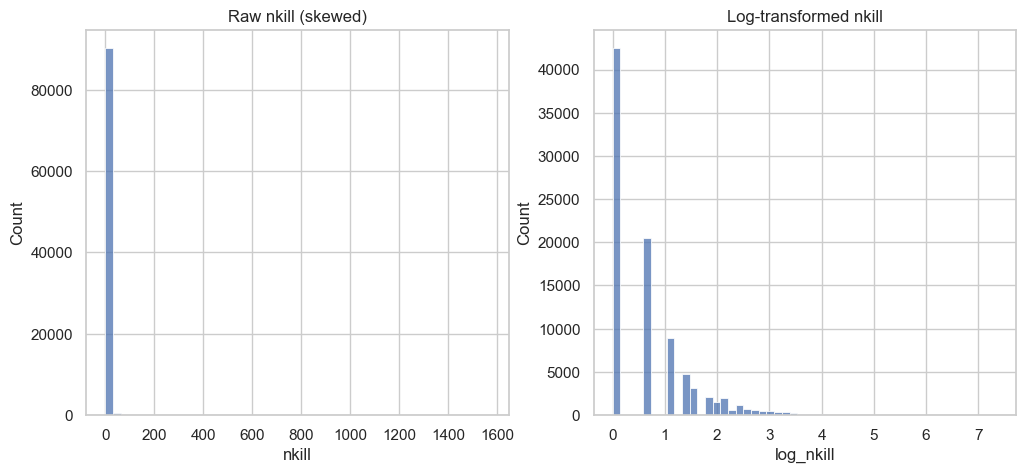

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_post2012['nkill'], bins=50, ax=axes[0])
axes[0].set_title("Raw nkill (skewed)")

sns.histplot(df_post2012['log_nkill'], bins=50, ax=axes[1])
axes[1].set_title("Log-transformed nkill")

plt.show()

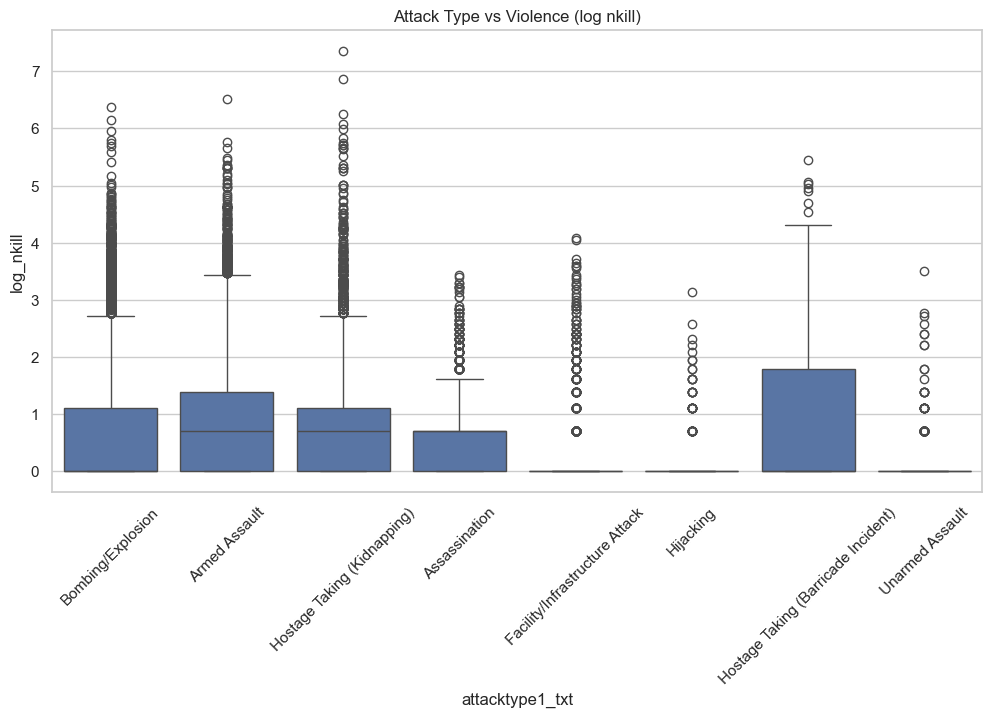

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_post2012, x='attacktype1_txt', y='log_nkill')
plt.xticks(rotation=45)
plt.title("Attack Type vs Violence (log nkill)")
plt.show()

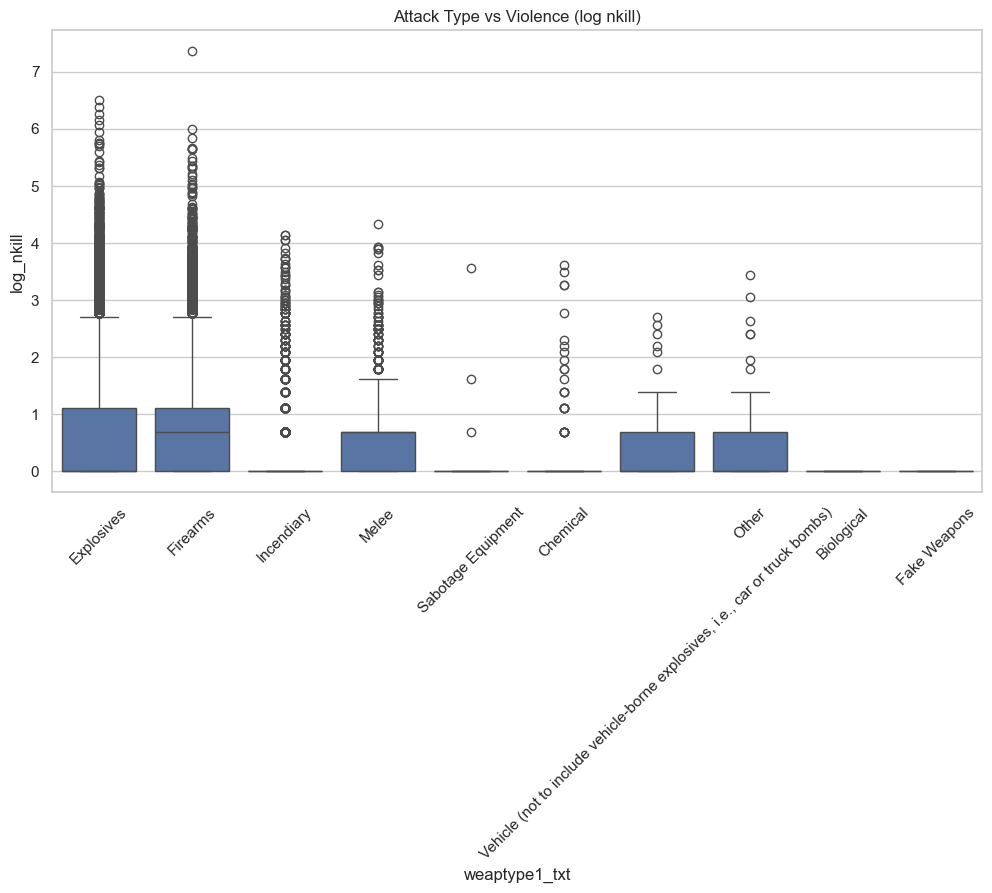

In [39]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_post2012, x='weaptype1_txt', y='log_nkill')
plt.xticks(rotation=45)
plt.title("Attack Type vs Violence (log nkill)")
plt.show()

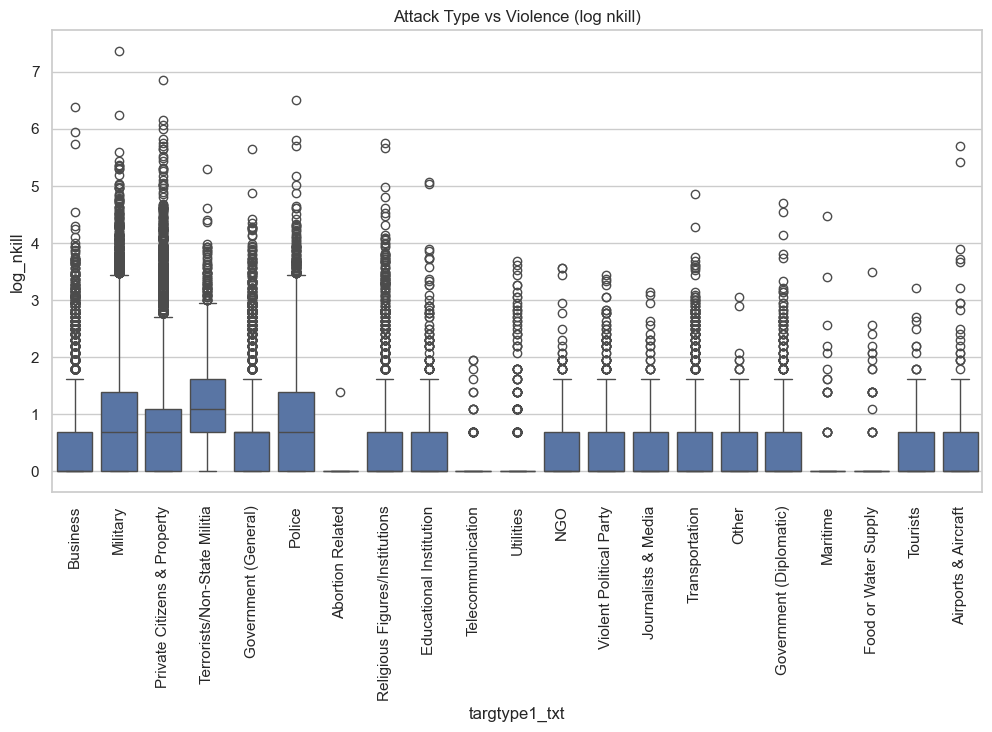

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_post2012, x='targtype1_txt', y='log_nkill')
plt.xticks(rotation=90)
plt.title("Attack Type vs Violence (log nkill)")
plt.show()

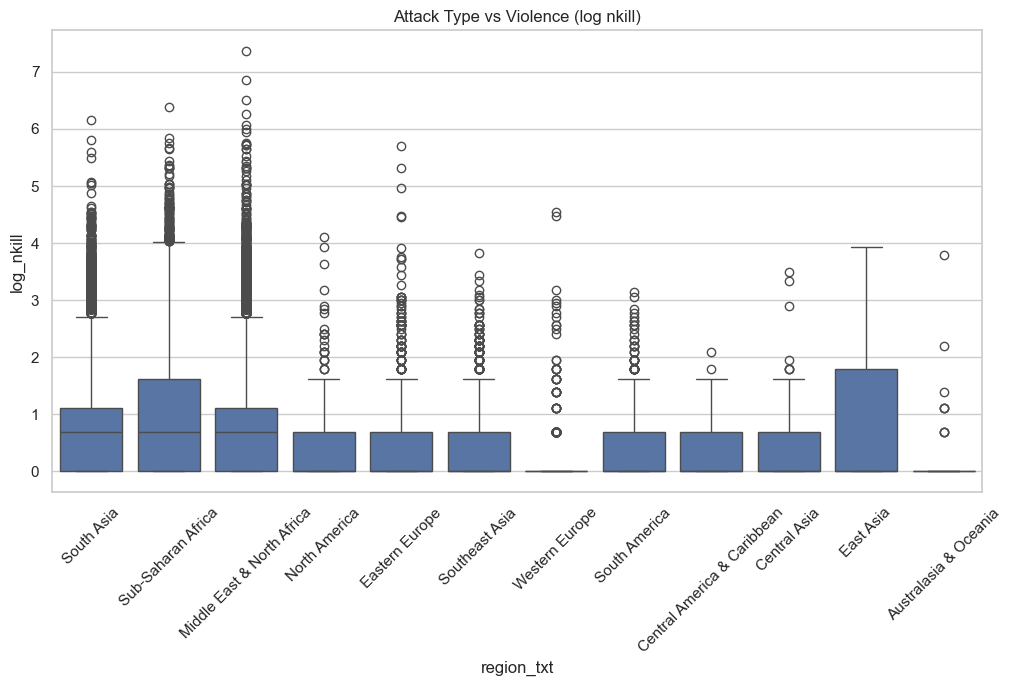

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_post2012, x='region_txt', y='log_nkill')
plt.xticks(rotation=45)
plt.title("Attack Type vs Violence (log nkill)")
plt.show()

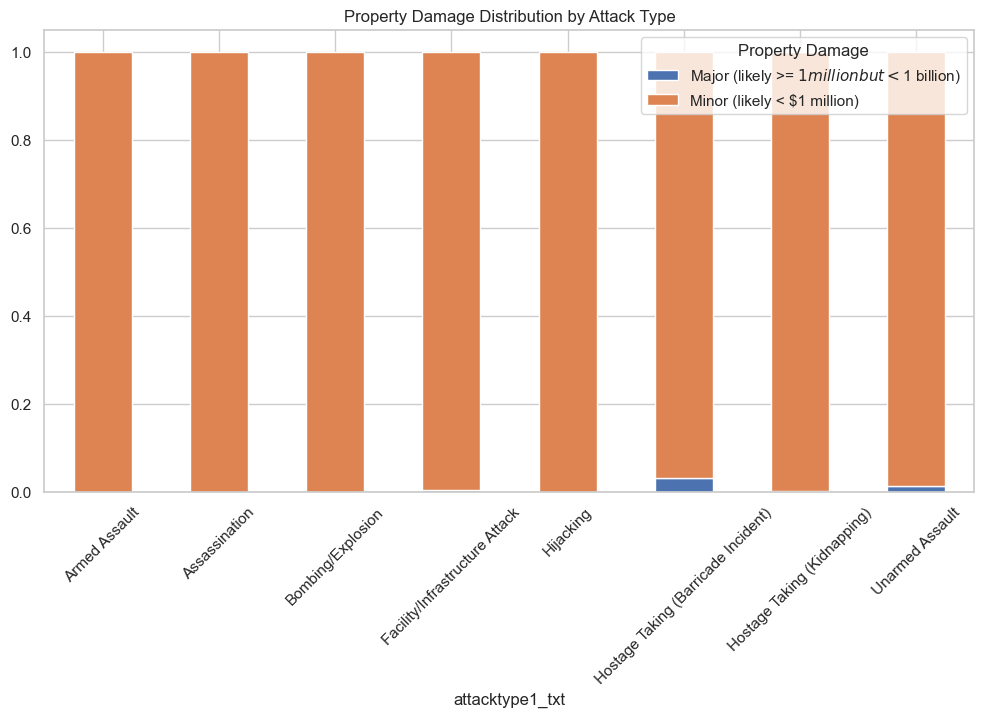

In [45]:
prop_dist = pd.crosstab(df_post2012['attacktype1_txt'], df_post2012['propextent_txt'], normalize='index')

prop_dist.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Property Damage Distribution by Attack Type")
plt.legend(title="Property Damage")
plt.xticks(rotation=45)
plt.show()

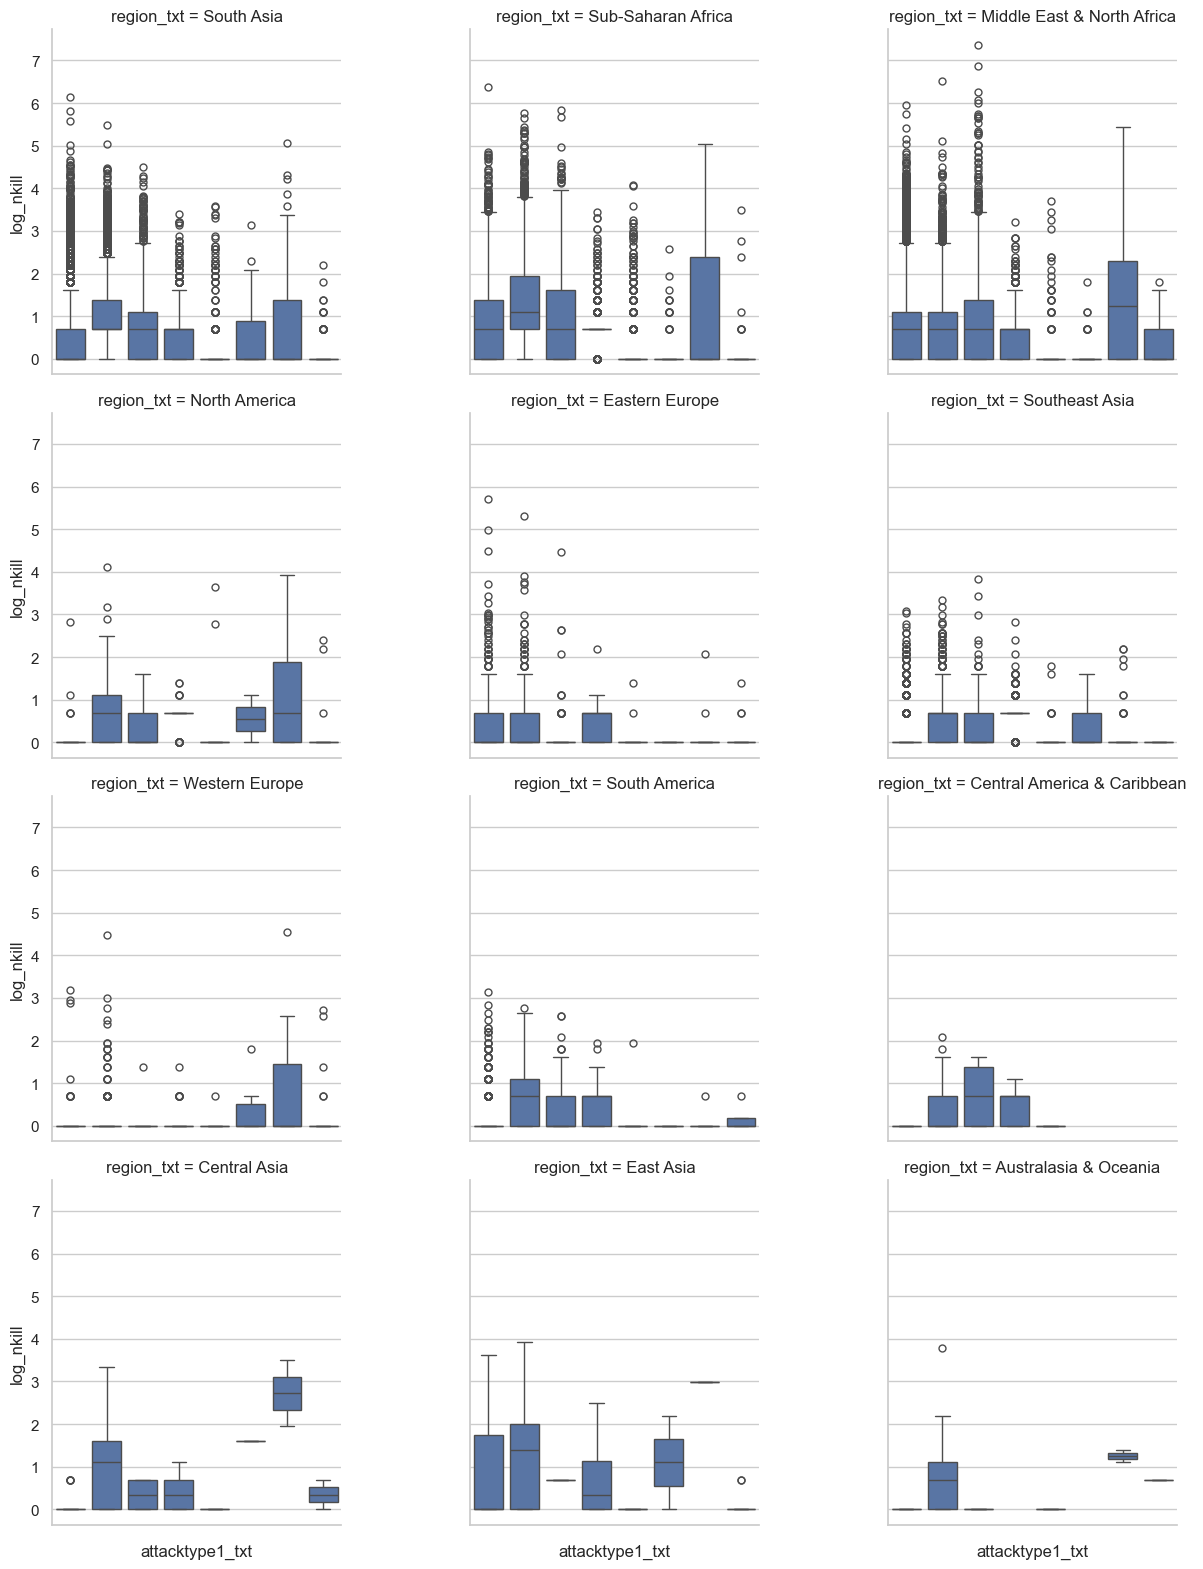

In [47]:
g = sns.catplot(
    data=df_post2012,
    x='attacktype1_txt',
    y='log_nkill',
    col='region_txt',
    kind='box',
    col_wrap=3,
    height=4
)

g.set_xticklabels(rotation=45)

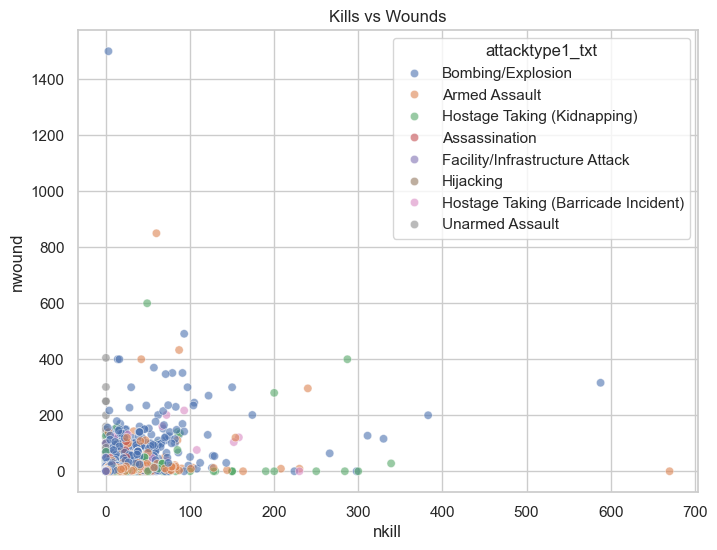

In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_post2012,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.show()

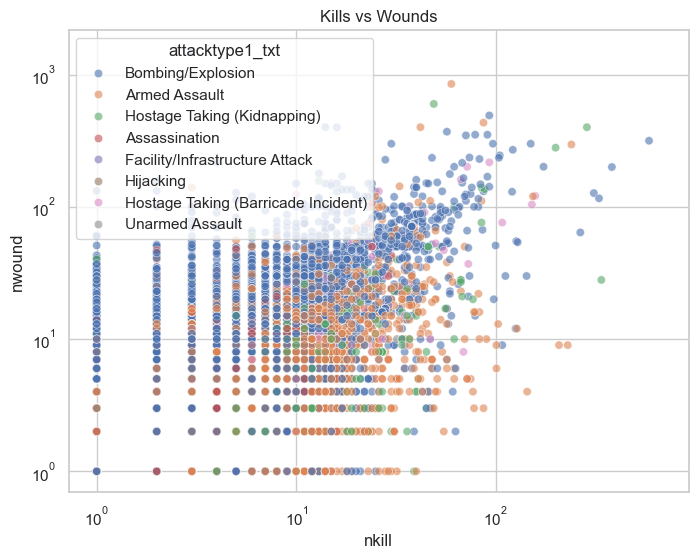

In [53]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_post2012,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.xscale('log')
plt.yscale('log')
plt.title("Kills vs Wounds")
plt.show()

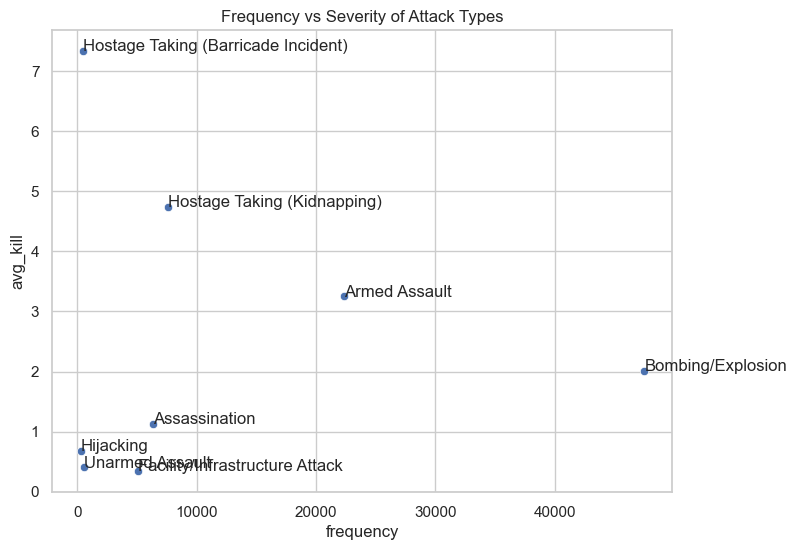

In [57]:
freq = df_post2012['attacktype1_txt'].value_counts()
severity = df_post2012.groupby('attacktype1_txt')['nkill'].mean()

summary = pd.DataFrame({
    'frequency': freq,
    'avg_kill': severity
}).dropna()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=summary, x='frequency', y='avg_kill')

for i in summary.index:
    plt.text(summary.loc[i, 'frequency'], summary.loc[i, 'avg_kill'], i)

plt.xscale('log')
plt.title("Frequency vs Severity of Attack Types")
plt.show()